# 05 Business Output

**Goal:** Train the deployment model on all clean data, explain it, and generate the priority customer list for the retention team.

Covers: deployment model fit, permutation feature importance (held-out month), SHAP feature attributions, priority-list scoring, risk-tier assignment, risk-band profiling, and the exported call list.


In [47]:
import warnings; warnings.filterwarnings('ignore')
import pickle
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import set_config
set_config(transform_output='pandas')
from sklearn.pipeline import Pipeline as _Pipeline
from sklearn.inspection import permutation_importance

from src.config import SEED
from src.pipelines import ALL_FEATURES, make_boost_pipeline
from src.evaluation import calibrate_isotonic
from src.reporting import plot_feature_importance, plot_risk_band_profiles


## 1. Load Artifacts

In [40]:
master = pd.read_parquet('artifacts/master.parquet', engine='pyarrow')
master['datevalue'] = pd.to_datetime(master['datevalue'])

with open('artifacts/data_end.txt') as f:
    DATA_END = pd.Timestamp(f.read().strip())

with open('artifacts/window_results.pkl', 'rb') as f:
    _saved = pickle.load(f)
window_results = _saved['window_results']
obs_months     = _saved['obs_months']

print(f'master: {master.shape}  |  DATA_END: {DATA_END.date()}')

all_y     = np.concatenate([r['y_test']     for r in window_results])
boost_all = np.concatenate([r['boost_prob'] for r in window_results])

master: (3292482, 69)  |  DATA_END: 2024-05-01


## 2. Deployment Model

Fit on **all** right-censoring-clean rows (all observation months ≤ DATA_END).
This is the model used to score new customers — it sees the most training data.

In [41]:
df_final = master[master['datevalue'] <= DATA_END].copy()
X_final, y_final = df_final[ALL_FEATURES], df_final['label']

final_boost = make_boost_pipeline().fit(X_final, y_final)
print(f'Deployment model fitted on {len(X_final):,} rows, '
      f'{df_final["datevalue"].nunique()} months')

Deployment model fitted on 2,982,846 rows, 22 months


**Why refit on all data?** The CV in notebooks 03–04 was for honest *evaluation*; this model is for *deployment*. Refitting on all 22 months of clean history gives the scorer maximum context and the best calibration on recent behaviour. The trade-off: because May 2024 customers are both in the training set and being scored, the tier probabilities below are in-sample estimates. The honest OOS figures — ROC-AUC 0.891, PR-AUC 0.640 — are those from notebook 04.

## 3. Permutation Feature Importance

Measured on a **held-out month** (the final observation month), not the training data.
The model is refitted on all months except the last, then permutation importance is
evaluated on the unseen final month — this reduces in-sample optimism by evaluating importance on unseen data.

Each feature's importance = mean ROC-AUC drop when that feature is randomly shuffled.

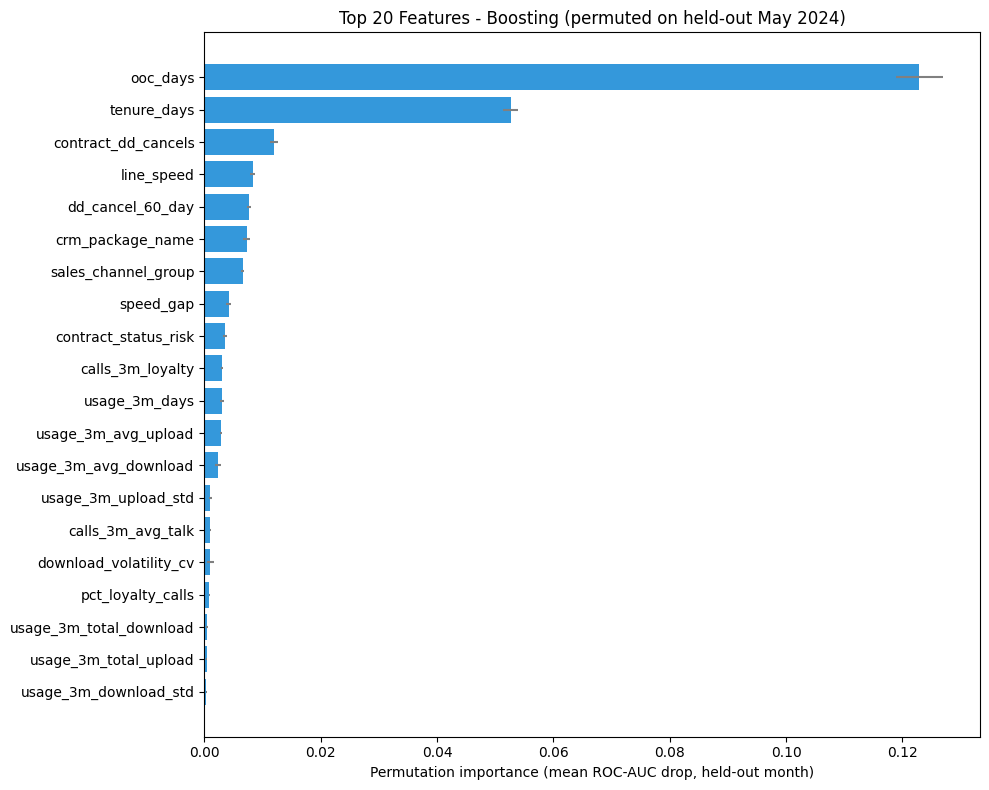


Top 20 features (held-out-month permutation importance):
                feature  importance_mean  importance_std
               ooc_days         0.122927        0.004061
            tenure_days         0.052718        0.001285
    contract_dd_cancels         0.012028        0.000697
             line_speed         0.008323        0.000474
       dd_cancel_60_day         0.007645        0.000310
       crm_package_name         0.007275        0.000542
    sales_channel_group         0.006593        0.000210
              speed_gap         0.004189        0.000463
   contract_status_risk         0.003519        0.000368
       calls_3m_loyalty         0.003073        0.000150
          usage_3m_days         0.003046        0.000339
    usage_3m_avg_upload         0.002897        0.000244
  usage_3m_avg_download         0.002363        0.000471
    usage_3m_upload_std         0.001056        0.000250
      calls_3m_avg_talk         0.001041        0.000131
 download_volatility_cv       

In [42]:
imp_test_month   = obs_months[-1]
imp_train_months = obs_months[:-1]
imp_tr = df_final[df_final['datevalue'].isin(imp_train_months)]
imp_te = df_final[df_final['datevalue'] == imp_test_month]
imp_boost = make_boost_pipeline().fit(imp_tr[ALL_FEATURES], imp_tr['label'])

rng    = np.random.default_rng(SEED)
te_idx = rng.choice(len(imp_te), size=min(20_000, len(imp_te)), replace=False)
perm   = permutation_importance(
    imp_boost, imp_te[ALL_FEATURES].iloc[te_idx], imp_te['label'].iloc[te_idx],
    n_repeats=5, scoring='roc_auc', random_state=SEED, n_jobs=-1,
)

fi_boost = (
    pd.DataFrame({'feature': ALL_FEATURES,
                  'importance_mean': perm.importances_mean,
                  'importance_std':  perm.importances_std})
    .sort_values('importance_mean', ascending=False)
    .reset_index(drop=True)
)

plot_feature_importance(fi_boost, pd.Timestamp(imp_test_month).strftime('%b %Y'))
print('\nTop 20 features (held-out-month permutation importance):')
print(fi_boost.head(20).to_string(index=False))

## 4. SHAP Feature Importance

SHAP (SHapley Additive exPlanations) explains each prediction by attributing a contribution to every feature. Computed on the same **held-out month** used for permutation importance above — so importance is measured on unseen data.

The beeswarm plot shows both **direction** (left = lowers churn risk, right = raises it) and **magnitude** simultaneously. Each dot is one customer; colour encodes feature value (red = high, blue = low).

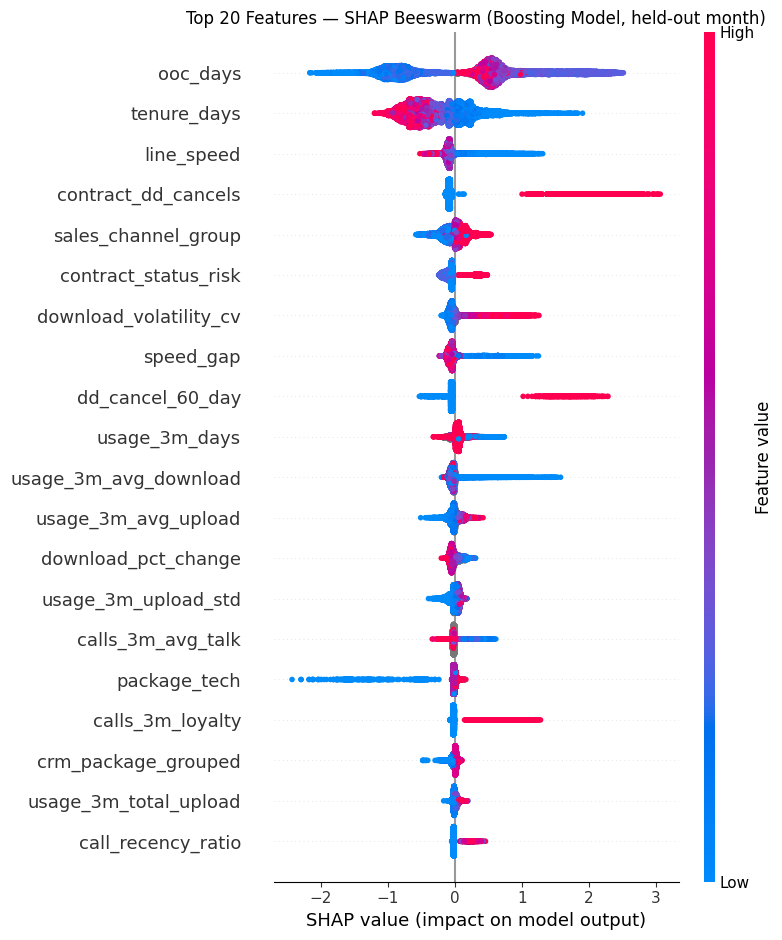

In [43]:
# Transform held-out data through preprocessing steps only (no model step)
_pre     = _Pipeline(imp_boost.steps[:-1])
X_shap   = _pre.transform(imp_te[ALL_FEATURES].iloc[te_idx])

explainer = shap.TreeExplainer(imp_boost.named_steps['model'])
shap_vals = explainer.shap_values(X_shap)

# Normalise to a 2-D (n_samples, n_features) array for the positive (churn) class,
# handling both the older list-per-class API and the newer 3-D array API.
if isinstance(shap_vals, list):
    shap_vals = shap_vals[1]
elif getattr(shap_vals, 'ndim', 2) == 3:
    shap_vals = shap_vals[..., 1]

# shap's built-in beeswarm — no custom reporting helper required
shap.summary_plot(shap_vals, X_shap, max_display=20, show=False)
plt.title('Top 20 Features — SHAP Beeswarm (Boosting Model, held-out month)')
plt.tight_layout()
plt.show()


 **Reading the chart.** `ooc_days` and `tenure_days` dominate — high OOC days (red, far right) push strongly toward churn, while long tenure (red, far left) pulls it down. Below them, payment stress (`contract_dd_cancels`, `dd_cancel_60_day`) and the speed signal (`line_speed`, `speed_gap` — customers sold a headline speed they don't actually receive) sit on the high-risk side. Unlike the LR coefficients, SHAP captures the non-linear threshold effect: `ooc_days` risk jumps around end-of-contract rather than rising linearly.


## 5. Priority Customer List

Score all customers in the **latest clean snapshot** (DATA_END month).

**Two scores per customer:**
- `churn_score`: raw model output — use for **ranking and prioritisation** (reliable, monotone; do not interpret as a probability)
- `calibrated_prob`: isotonic-calibrated probability — use for **business communication and expected-value calculations** (scaled to match the ~12% observed churn rate)

Risk tiers are assigned by **score percentile** rather than raw-score cutoffs so they align with operational channel capacity. The min-cost analysis in notebook 04 recommends a broad-contact strategy: because a missed churner costs far more than an unnecessary call, the cost-optimal threshold deliberately flags a large share of the base. The tier system translates this into a priority order: P1/P2 take the top 10% through expensive phone channels, P3 reaches the next 20% via scalable email/SMS, and P4 is a watch list below the current channel-capacity cutoff — capacity, not cost, is the binding constraint on how far down the ranked list active outreach extends.

**Note:** The deployment model (`final_boost`) is trained on all data up to and including DATA_END (May 2024) and then scores the May 2024 snapshot — i.e. customers that were in its own training set. The tier scores therefore represent in-sample estimates. The honest OOS performance figures are those reported in notebook 04. Separately, `iso_cal` was fit on the out-of-sample CV scores; applying it to in-sample deployment scores inherits the same caveat — treat `calibrated_prob` values here as indicative rather than precise.


In [44]:
iso_cal, _ = calibrate_isotonic(all_y, boost_all)

df_score = master[master['datevalue'] == DATA_END].copy()
raw_score = final_boost.predict_proba(df_score[ALL_FEATURES])[:, 1]
df_score['churn_score']     = raw_score
df_score['calibrated_prob'] = iso_cal.predict(raw_score)

pct = df_score['churn_score'].rank(pct=True)
df_score['risk_tier'] = pd.cut(
    pct, bins=[0, 0.70, 0.90, 0.97, 1.0],
    labels=['P4 Monitor', 'P3 Email/SMS', 'P2 Outbound', 'P1 Call first'],
    include_lowest=True)

print(f'Customers scored for {DATA_END.date()}: {len(df_score):,}')
print(f'Raw score range    : {raw_score.min():.3f} - {raw_score.max():.3f}')
print(f'Calibrated prob    : {df_score["calibrated_prob"].min():.3f} - {df_score["calibrated_prob"].max():.3f}')
print('\nRisk tier breakdown:')
tier_tbl = (
    df_score.groupby('risk_tier', observed=True)
    .agg(customers=('churn_score','size'), mean_calibrated_prob=('calibrated_prob','mean'))
    .reindex(['P1 Call first','P2 Outbound','P3 Email/SMS','P4 Monitor'])
)
print(tier_tbl.to_string())

Customers scored for 2024-05-01: 86,365
Raw score range    : 0.004 - 0.995
Calibrated prob    : 0.000 - 1.000

Risk tier breakdown:
               customers  mean_calibrated_prob
risk_tier                                     
P1 Call first       2591              0.882920
P2 Outbound         6046              0.610881
P3 Email/SMS       17273              0.209184
P4 Monitor         60455              0.028088


## 6. Risk Band Diagnostic

Median feature values by risk tier — shows **why** each group is where it is.
P1 (highest risk) should show: high `ooc_days`, high `calls_3m_loyalty`,
low `tenure_days` (or very high — U-shaped), and more DD cancellations.

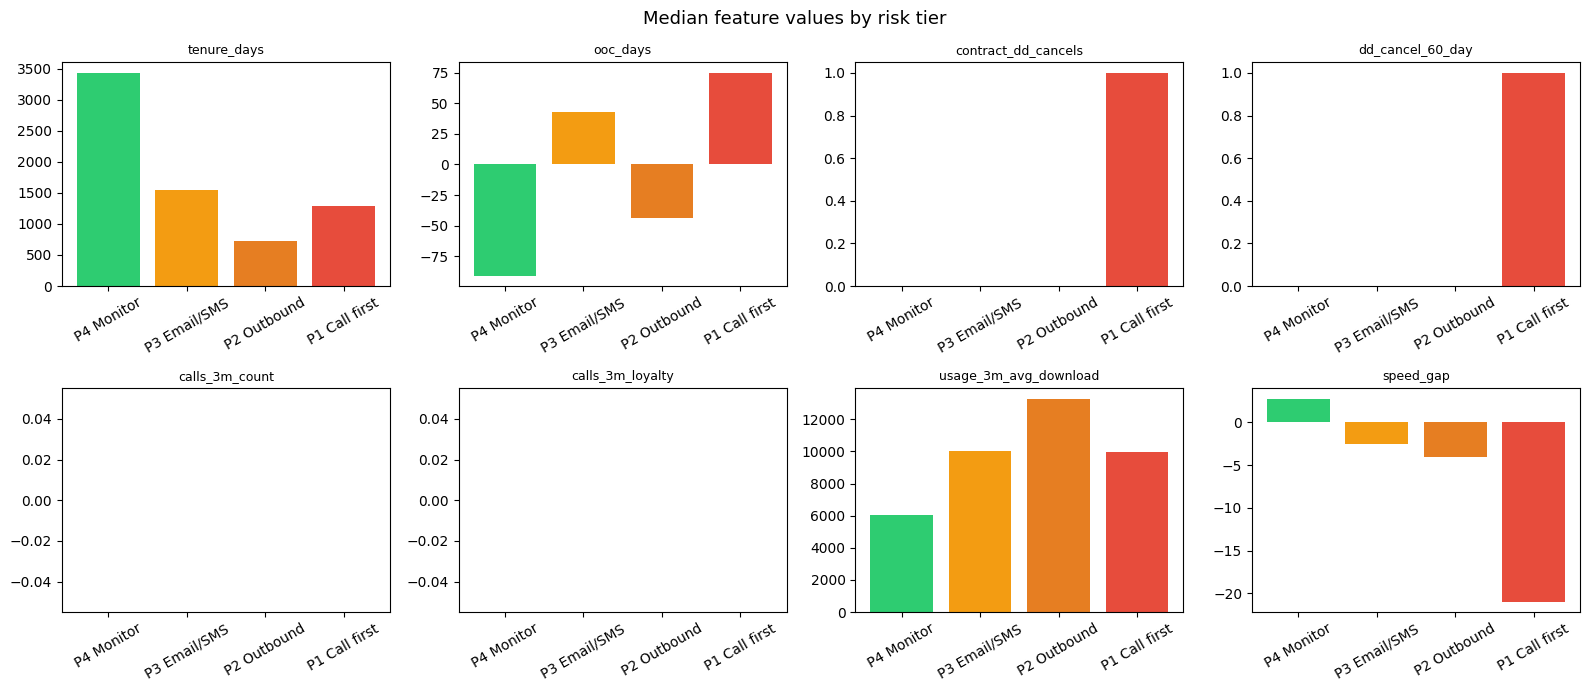

In [45]:
plot_risk_band_profiles(df_score)

> **The sanity check.** Moving from P4 up to P1: median `ooc_days` climbs, DD cancellations climb, and tenure falls. The tier profiles match exactly the churner signature that EDA and SHAP both pointed to. Internal consistency across the ranking model, feature importance, and segment profiles is the final validation before handing over the list.

## 7. Export Priority List

In [48]:
top_customers = (
    df_score[['unique_customer_identifier', 'churn_score', 'calibrated_prob',
               'risk_tier', 'contract_status', 'tenure_days', 'ooc_days',
               'technology', 'calls_3m_loyalty', 'calls_3m_count']]
    .sort_values('churn_score', ascending=False)
    .head(1000)
)
top_customers.to_csv('top_churn_risk_customers.csv', index=False)
print(f'Top 1,000 at-risk customers saved to top_churn_risk_customers.csv')
top_customers.head(10)

Top 1,000 at-risk customers saved to top_churn_risk_customers.csv


,unique_customer_identifier,churn_score,calibrated_prob,risk_tier,contract_status,tenure_days,ooc_days,technology,calls_3m_loyalty,calls_3m_count
467194,051f01f8f85576c3c01608a6e3269d3ff05fb3ee53aa5d...,0.994718,1.000000,P1 Call first,06 OOC,1846,362.0,GFAST,1.0,1.0
3268266,3b527f1ff0c28ce06f8ec987e72c1fc483e3ddfeda9c34...,0.994645,1.000000,P1 Call first,05 Newly OOC,3796,8.0,FTTC,0.0,0.0
8098,a44f123e47c1bf1786f78d756d83c858a2e83ff64d0d69...,0.994380,1.000000,P1 Call first,06 OOC,5137,177.0,MPF,0.0,0.0
1070908,f3941b25410e7ec8df356171af2bcfe0da7be0d429a62d...,0.994224,1.000000,P1 Call first,06 OOC,5110,221.0,FTTC,0.0,0.0
621309,fd41286532cac7c101e9feabc91f01b8296d8f37882c27...,0.994215,1.000000,P1 Call first,06 OOC,4739,1459.0,FTTC,0.0,0.0
2167570,8fd23be1e72c2406cb52bf7fe0482efd93bd421fa14f2d...,0.994125,1.000000,P1 Call first,06 OOC,5648,236.0,FTTC,0.0,0.0
1355161,af73815a21698b45eeca963f5bf12648f6fd24f3039724...,0.994100,0.997295,P1 Call first,06 OOC,7118,362.0,FTTC,0.0,0.0
2919229,fe0d490f50f2b5437cb06d6cd491bf97d2d4634d660e7f...,0.994072,0.985655,P1 Call first,06 OOC,6062,1499.0,FTTC,0.0,0.0
3124136,079145a9bc1fa8f6c11751dd20b5fa6b3671f4dc44ff63...,0.993920,0.976744,P1 Call first,06 OOC,6593,1198.0,FTTC,0.0,0.0
1881351,db78afef548d26081d0fe7d72bae2a6121f13d36681684...,0.993903,0.976744,P1 Call first,05 Newly OOC,1973,89.0,FTTC,2.0,2.0


> **What's in the CSV.** Each row is one at-risk customer with: unique ID, raw `churn_score` (for ordering), `calibrated_prob` (for quoting), risk tier, and key context fields — contract status, tenure, OOC days, recent loyalty calls. An agent can pick up the phone with a reason in hand rather than a bare customer ID.